# Explorando factores de comportamiento en NovaRetail+

**Herramientas:** Python (pandas, NumPy, seaborn, matplotlib, SciPy).


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** buscaba responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este es un análisis **correlacional** (exploratorio). **Correlación ≠ causalidad.**


## Sección 1 - Cargar y explorar el dataset

En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

Antes de correlacionar, primero entendemos el “terreno”.

In [1]:
# Importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


### Cargar Dataset

In [2]:
# Cargar el dataset y explorar datos
df = pd.read_csv('/datasets/novaretail_comportamiento_clientes_2024.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [3]:
# mostrar las primeras 5 filas
df.head(5)




,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza

**Cambios necesarios:** `edad` está en `float64` y debe convertirse a `int64`. `miembro_premium` y `abandono` están codificadas como `int64` (0/1), pero son variables categóricas/binarias, no cantidades.


#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**
Se identifican las siguientes columnas numéricas:
- `edad`
- `nivel_ingreso`
- `visitas_mes`
- `compras_mes`
- `gasto_publicidad_dirigida`
- `satisfaccion`
- `ingreso_anual`

La mayoría de estas variables presentan tipos de datos adecuados. La columna `edad` está en `float64` con decimales y debe convertirse a `int64` para obtener valores enteros.

**Variables binarias**
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**
Se identifican las siguientes columnas categóricas:
- `id_cliente`
- `tipo_dispositivo`
- `region`

Estas variables están correctamente definidas y no requieren transformación adicional.


In [4]:
# Corregir el tipo de dato
df['edad'] = df['edad'].astype('int64')

In [5]:
# verificar cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  int64  
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(4), int64(5), object(3)
memory usage: 1.4+ MB


#### Explorar variables numéricas

In [6]:
# Estadísticas descriptivas de variables numéricas
df.describe()

,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,ingreso_anual
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,3.603693,0.139267,0.150733,36.594180
std,11.492378,9833.166305,3.158189,1.105284,10.880724,0.685300,0.346236,0.357801,34.484888
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,3.100000,0.000000,0.000000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,3.600000,0.000000,0.000000,30.705000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,4.100000,0.000000,0.000000,58.220000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,5.000000,1.000000,1.000000,244.690000


✍️ **Comentario**: 

Diagnóstico inicial de variables numéricas

- `edad`: La media de 38 años es coherente y el rango 18–75 es válido y esperado para una plataforma de e-commerce.
- `Nivel_ingreso`: Es mucha la diferencia de la media de ingreso a la cantidad maxima eso quiere decir que  hay mas usuarios con ingresos menores a 30.000. Cabe notar que la diferencia entre media y máximo es clave para detectar distribuciones sesgadas.
- `Gasto_publicidad`: El mínimo en 0 es una señal importante de segmentación en la estrategia publicitaria.
- `Visitas_mes`: La media y la mediana son similares (≈10), lo que sugiere una distribución relativamente simétrica.
La frecuencia de visitas es moderada, con la mayoría de clientes entre 8 y 12 visitas al mes (rango intercuartílico).
- `Compras_mes `: El 25 % de los clientes tiene compras en 0. Relacionar que el 25% sin compras coincide con el 25% sin ingresos es un hallazgo analítico importante, puede verse relacionado con Ingreso_anual en una posible correlación que verificaremos más adelante.
- `Ingreso_anual`: El 25% de los clientes tiene ingreso anual de $0, lo que coincide con el 25% sin compras en el mes.
La media (≈36.6) es mayor que la mediana (≈30.7), lo que indica una distribución sesgada hacia la derecha por clientes de alto valor.

#### Explorar variables binarias

In [7]:
# Verificar que cada columna tenga únicamente dos valores posibles
print(df["miembro_premium"].value_counts())
print(df["abandono"].value_counts())


0    12911
1     2089
Name: miembro_premium, dtype: int64
0    12739
1     2261
Name: abandono, dtype: int64


✍️ **Diagnóstico inicial de variables binarias**

- `miembro_premium` — Base de clientes premium pequeña (~14%). Aumentar ese porcentaje podría representar mayores ingresos para NovaRetail+.
- `abandono` — El 15% es un porcentaje relevante y preocupante. Vale la pena cruzarlo con `ingreso_anual` y `compras_mes`, especialmente considerando que el 25% de los clientes tiene valores en 0.


#### Explorar variables categóricas

In [8]:
# Verificar el número de valores únicos por variable categórica
print(df["tipo_dispositivo"].value_counts())
print(df["region"].value_counts())

móvil         9818
escritorio    3720
tablet        1462
Name: tipo_dispositivo, dtype: int64
norte    4395
oeste    3810
sur      3726
este     3069
Name: region, dtype: int64


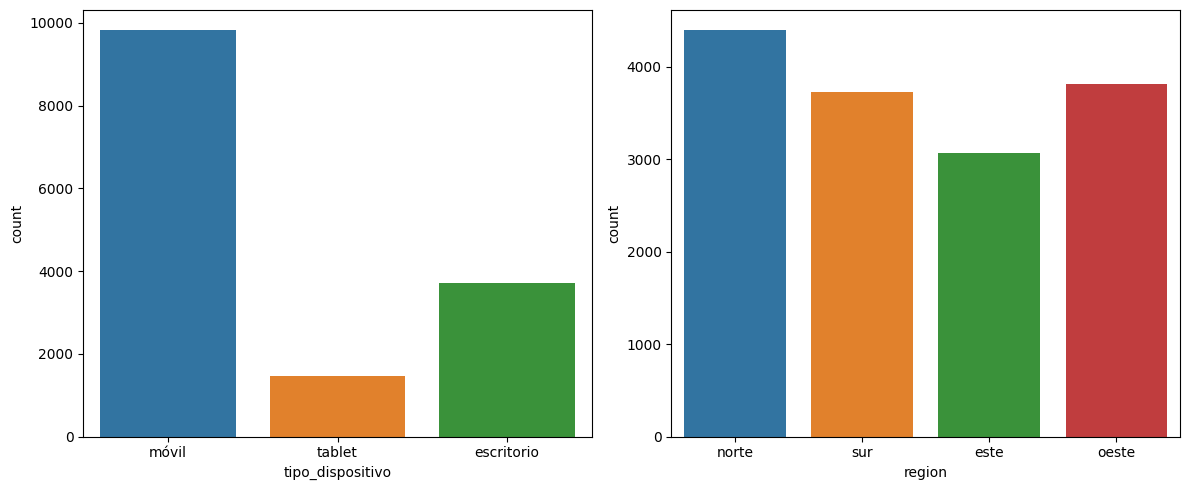

In [9]:
# Explorar variables categóricas y cómo se distribuyen
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(data=df, x="tipo_dispositivo", ax=axes[0])
sns.countplot(data=df, x="region", ax=axes[1])

plt.tight_layout()
plt.show()

✍️ **Comentario**: Se evidencia que móvil es la categoría que tiene mayor dominio entre las demás, y el norte domina también frente a las demás regiones. El desequilibrio en `tipo_dispositivo` (móvil representa el 65% de los usuarios) podría sesgar comparaciones de `ingreso_anual` entre grupos, ya que el grupo móvil tiene muchos más datos que tablet o escritorio.

**Diagnóstico inicial de variables categóricas**

- `tipo_dispositivo` — móvil domina con 9,818 usuarios
- `region` — norte lidera con 4,395 usuarios, y las demás regiones están bastante equilibradas


### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

Text(0.5, 1.0, 'Correlación de variables numéricas')

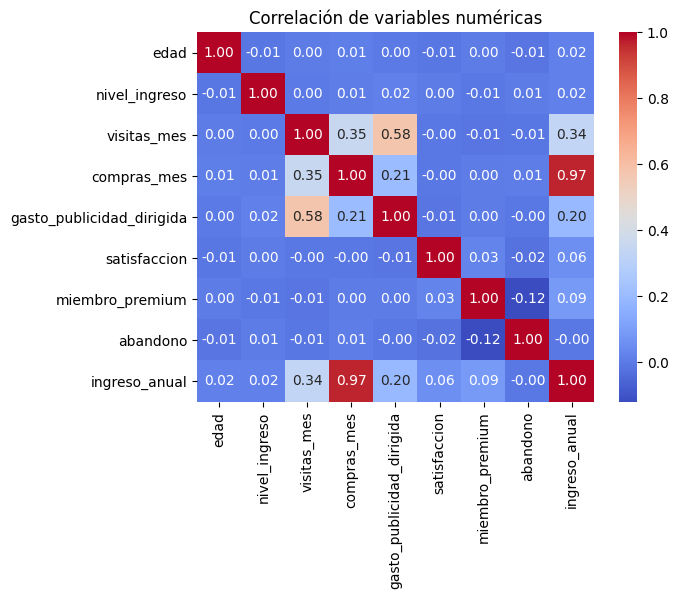

In [10]:
# Visualizar la matriz de correlación para identificar relaciones
sns.heatmap( df.corr( ), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlación de variables numéricas")

✍️ **Comentario**: Se evidencia una fuerte correlación positiva con `compras_mes` e `ingreso_anual`, la mayoría de variables tienen correlación débiles entre si, exceptuando las ya mencionadas y `abandono` y `miembro_premium` presentan una correlación débil negativa.


Observaciones generales (Heatmap)  
- Se observa que `abandono` y `miembro_premium` tienen una correlacion muy débil negativa en azul, `compras_mes` e `ingreso_anual` tienen una correlación positiva fuerte, `visitas_mes` y `gasto_publicidad_dirigida` tienen una correlacion positiva mediana-fuerte, `compras_mes` y `visitas_mes` tienen una correlación positiva debil, de la misma forma que `visitas_mes` e `ingreso_anual` una correlación positiva debil.


Observaciones respecto a `ingreso_anual`  
- Presenta variables que tienen mayor relación con `ingreso_anual` son `compras_mes` y `visitas_mes` con una correlación positiva fuerte, y una correlación positiva débil con`gasto_publicidad_dirigida`.


### Scatterplot general

### Scatterplot para pares clave

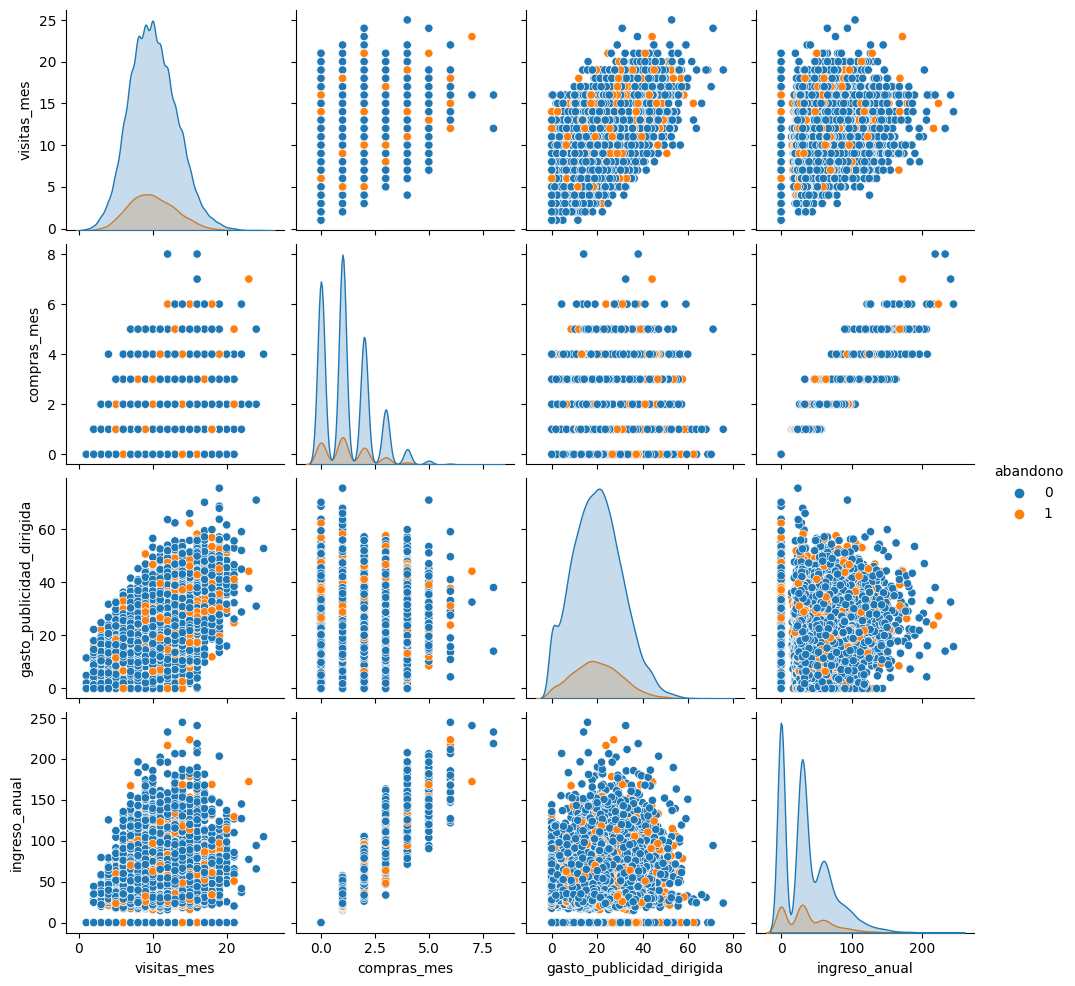

In [11]:
# Visualizar pares de variables con relaciones moderadas o fuertes
sns.pairplot(data=df, vars=["visitas_mes","compras_mes","gasto_publicidad_dirigida","ingreso_anual"], hue="abandono")

✍️ **Comentario**: Los resultados sugieren que los ingresos anuales tienen una fuerte relación con la frecuencia de compra. Además, la publicidad dirigida parece contribuir al incremento de visitas, aunque con una variabilidad considerable. Finalmente, el análisis por abandono indica que los clientes que visitan frecuentemente el sitio pero realizan pocas compras presentan una mayor tendencia a abandonar, lo que representa una oportunidad para implementar estrategias de conversión y retención más efectivas.


Observaciones iniciales (Scatterplot)

**compras_mes vs ingreso_anual**
Dirección: Se observa una relación positiva fuerte; a medida que aumenta el ingreso anual, también aumenta el número de compras mensuales.
Dispersión: Baja, con los puntos concentrados alrededor de la tendencia principal.
Outliers: No se identifican valores atípicos relevantes que alteren el patrón general.
Colinealidad: Alta (r ≈ 0.97), lo que indica una fuerte asociación lineal entre ambas variables. Los clientes que abandonan también presentan niveles relativamente altos de compras.

**visitas_mes vs gasto_publicidad_dirigida**
Dirección: Se aprecia una relación positiva moderada; un mayor gasto en publicidad dirigida suele estar asociado con un mayor número de visitas mensuales.
Dispersión: Moderada-alta, mostrando una mayor variabilidad que el par anterior.
Outliers: No se observan valores atípicos significativos que afecten la tendencia general.
Colinealidad: Moderada, lo que sugiere una asociación positiva, aunque menos fuerte. Los clientes retenidos parecen beneficiarse más de la publicidad dirigida.

**visitas_mes vs abandono (hue)**
Dirección: La relación entre visitas y compras es positiva para ambos grupos de clientes.
Dispersión: Los clientes que abandonan muestran una mayor dispersión en comparación con los que permanecen activos.
Outliers: Se observan algunos casos de clientes con muchas visitas pero pocas compras.
Colinealidad: Positiva moderada; los clientes que realizan muchas visitas sin convertirlas en compras presentan una mayor probabilidad de abandono.

## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [12]:
# Calcular correlación entre variables relevantes
from scipy.stats import chi2_contingency
from scipy.stats import spearmanr
r, p = spearmanr(df["ingreso_anual"], df["compras_mes"])
print(f"Spearman: r={r:.4f}, p={p:.4f}")



Spearman: r=0.9675, p=0.0000


In [13]:
# Calcular correlación entre variables relevantes

from scipy.stats import pearsonr
r, p = pearsonr(df["ingreso_anual"], df["visitas_mes"])
print(f"Pearsonr: r={r:.4f}, p={p:.4f}"
)


Pearsonr: r=0.3371, p=0.0000


✍️ **Comentario**: Los resultados indican que el ingreso anual está fuertemente relacionado con la cantidad de compras realizadas por los clientes, lo que sugiere que el poder adquisitivo influye significativamente en el comportamiento de compra. Sin embargo, la relación entre ingreso anual y número de visitas es considerablemente más débil, lo que implica que visitar más la plataforma no necesariamente está asociado con mayores ingresos. Por ello, para estrategias de negocio y modelos analíticos, la variable compras_mes parece tener una relación más relevante con ingreso_anual que visitas_mes.


Observaciones de correlación

**ingreso_anual vs compras_mes**
- Se observa una correlación positiva muy fuerte entre ambas variables (ρ = 0.9675, p < 0.05). Esto indica que, en general, a medida que aumenta el ingreso anual de los clientes, también aumenta el número de compras mensuales. Debido a que el coeficiente es muy cercano a 1, podría existir una posible colinealidad entre estas variables, por lo que conviene considerarlo en futuros modelos predictivos.

**ingreso_anual vs visitas_mes (Pearson):**
- La correlación es positiva pero moderada-débil (r = 0.3371, p < 0.05). Esto sugiere que los clientes con mayores ingresos tienden a realizar más visitas, aunque la relación no es lo suficientemente fuerte como para indicar una dependencia importante entre ambas variables. Además, el riesgo de colinealidad es bajo debido a la magnitud relativamente pequeña del coeficiente.

### Punto-biserial

In [14]:
# Calcular correlación entre variables relevantes

from scipy.stats import pointbiserialr
r, p = pointbiserialr(df["miembro_premium"], df["ingreso_anual"])
print(f"pointbiserialr: r={r:.4f}, p={p:.4f}"
)
r, p = pointbiserialr(df["miembro_premium"], df["abandono"])
print(f"pointbiserialr: r={r:.4f}, p={p:.4f}"
)


pointbiserialr: r=0.0931, p=0.0000
pointbiserialr: r=-0.1205, p=0.0000


✍️ **Comentario**: El análisis punto-biserial muestra una relación positiva pero muy débil entre la membresía premium y el ingreso anual (r = 0.0931). Esto sugiere que los clientes con mayores ingresos tienen una ligera tendencia a pertenecer al programa premium, aunque la asociación es demasiado pequeña para considerarla un factor predictivo importante. Por lo tanto, es probable que otras variables, como el comportamiento de compra o la frecuencia de uso, tengan una mayor influencia en la adopción de la membresía premium.

Observaciones Punto-biserial

**miembro_premium vs ingreso_anual**
- Dirección: Positiva, ya que el coeficiente es mayor que cero (r = 0.0931).
Magnitud: Muy baja o débil, debido a que el valor está muy cerca de 0.
Interpretación: Existe una ligera tendencia a que los clientes premium tengan ingresos anuales más altos; sin embargo, la relación es muy débil y el hecho de ser miembro premium no parece estar fuertemente asociado con el nivel de ingresos.
Impacto para el negocio: Aunque la relación es estadísticamente significativa (p < 0.05), su magnitud es muy pequeña, por lo que el ingreso anual por sí solo probablemente no sea un factor determinante para explicar quién se convierte en miembro premium.

**abandono vs ingreso_anual**
- Dirección: Negativa, ya que el coeficiente es menor que cero (r = -0.1205).
Magnitud: Baja o débil, debido a que el valor está relativamente cerca de 0.
Interpretación: Existe una ligera tendencia a que los clientes con mayores ingresos anuales presenten menores tasas de abandono. Sin embargo, la relación es débil y el ingreso anual por sí solo no explica de manera importante el abandono de los clientes.
Impacto para el negocio: Aunque la relación es estadísticamente significativa (p < 0.05), la magnitud es reducida, por lo que probablemente existen otros factores más relevantes que influyen en la decisión de abandonar el servicio.

El análisis punto-biserial muestra una relación negativa y débil entre el ingreso anual y el abandono de clientes (r = -0.1205). Esto sugiere que los clientes con mayores ingresos tienden ligeramente a permanecer en la empresa, mientras que aquellos con ingresos más bajos presentan una mayor propensión al abandono. No obstante, debido a la baja magnitud de la correlación, el **ingreso anual no parece ser un predictor fuerte del abandono**, por lo que sería recomendable analizar variables adicionales relacionadas con el comportamiento de compra, satisfacción o nivel de interacción de los clientes.

### V de Cramér

In [15]:
# Función para calcular V de Cramér
tabla = pd.crosstab(df["tipo_dispositivo"], df["region"])
chi2, p, dof, expected = chi2_contingency(tabla)
n = tabla.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(tabla.shape) -1)))
print(cramers_v)

0.012378338407739397


In [16]:
# Aplicar V de Cramér en variables relevantes
tabla = pd.crosstab(df["miembro_premium"], df["abandono"])
chi2, p, dof, expected = chi2_contingency(tabla)
n = tabla.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(tabla.shape) -1)))
print(cramers_v)

0.12021874609740511


✍️ **Comentario**: Tiene muy poca asociación casi nula el tipo de dispositivo y la region en la que se encuentra el cliente. Un valor de 0.0124 nos dice que el tipo de dispositivo que usa un cliente es prácticamente independiente de la región donde se encuentra. En otras palabras, no importa si el cliente es de una región u otra, eso no influye en si usa móvil, tablet o computadora. En cuanto a miembro_premium y abandono hay una correlación débil (existe una pequeña asociación). Es decir que los clientes premium abandonan menos.


Observaciones V de Cramér

## Sección 5 - Interpretación de resultados para el negocio

Cada hallazgo se presenta con evidencia visual, evidencia numérica, interpretación (no causal) y su implicación de negocio.

---


In [17]:
from scipy.stats import pointbiserialr
r, p = pointbiserialr(df['abandono'], df['edad'])
print(f"Point-Biserial: r={r:.4f}, p={p:.4f}")

Point-Biserial: r=-0.0115, p=0.1590


### Hallazgo 1 — 
compras_mes vs ingreso_anual
**Evidencia visual:** scatterplot de compras_mes vs ingreso_anual
**Evidencia numérica:** con un r= 0.9675

**Interpretación**  
Existe una correlación fuerte y positiva entre compras_mes e ingreso_anual (ρ = 0.9675, p < 0.05), lo que indica que a mayor compras_mes, mayor ingreso_anual

**No podemos afirmar**  
No podemos concluir causalidad. Es explícitamente correlacional y exploratorio, no causal. ρ = 0.9675 es una correlación muy fuerte y positiva, pero no permite concluir causalidad, lo que podría llevarnos a pensar en una variable como edad, para corroborar que no es causalidad la correlación entre compras_mes y ingresos_anual, al tener personas con mayor edad mas estabilidad financiera que una persona de menor edad, y no tener esa liquidez financiera como una persona mayor.

**Implicación de negocio**  
Hallazgo: Existe una correlación muy fuerte entre compras mensuales e ingreso anual (ρ = 0.9675).

Acción: Incrementar la frecuencia de compra mediante programas de fidelización y ofertas dirigidas.

Resultado esperado: Aumento del ingreso anual y mejora de la retención de clientes.


### Hallazgo 2 — 
ingreso_anual vs visitas_mes
**Evidencia visual:**  Scatterplot de visitas_mes vs ingreso_anual (pairplot, celda 35)
**Evidencia numérica:** Pearsonr: r=0.3371, p=0.0000

**Interpretación**  
El coeficiente de correlación de Pearson (r = 0.3371) indica una relación positiva moderada entre las variables analizadas. Esto significa que, en promedio, cuando una variable aumenta, la otra también tiende a aumentar. Sin embargo, la intensidad de la relación no es lo suficientemente fuerte como para afirmar una dependencia importante entre ambas variables.

**No podemos afirmar**  
No podemos afirmar que incrementar las visitas mensuales aumentará directamente el ingreso anual de los clientes. La correlación encontrada sugiere una relación positiva, pero no proporciona evidencia suficiente para concluir que una variable sea la causa de la otra.

**Implicación de negocio** 
Aunque los clientes con mayores ingresos tienden a realizar más visitas mensuales, la relación es solo moderada. Esto sugiere que incrementar el tráfico o las visitas por sí solo no garantizará un aumento significativo en los ingresos. Por ello, NovaRetail+ debería complementar sus estrategias de adquisición de tráfico con acciones enfocadas en mejorar la conversión y la frecuencia de compra.

Hallazgo: Más visitas ↗️ se relacionan con más ingresos ↗️

Pero: La relación no es muy fuerte.

Acción: No basta con atraer visitantes; hay que convertirlos en compradores recurrentes.


## Sección 6 - Limitaciones y próximos pasos

### **Limitaciones**
- Correlación ≠ causalidad
- Este análisis presenta varias limitaciones que deben considerarse al interpretar los resultados. En primer lugar, las correlaciones identificadas permiten detectar asociaciones entre variables, pero no establecer relaciones de causa y efecto. Por lo tanto, no es posible afirmar que una variable provoque cambios directos en otra.

Además, el conjunto de datos no incluye variables potencialmente relevantes para explicar el comportamiento de los clientes, como nivel de satisfacción, historial de servicio al cliente, promociones recibidas o motivos específicos de abandono. La ausencia de estas variables limita la capacidad de comprender completamente los factores que influyen en la retención y las compras.

Asimismo, la distribución de algunas categorías, como el tipo de dispositivo, no es completamente equilibrada, por lo que ciertos grupos de clientes pueden estar menos representados que otros. Esto podría afectar la generalización de algunos hallazgos a toda la población de clientes.

Finalmente, este análisis es descriptivo y exploratorio, basado en datos históricos. Por ello, los resultados no deben utilizarse para predecir comportamientos futuros sin desarrollar y validar previamente modelos predictivos específicos.

### **Próximos pasos** 

El análisis exploratorio de NovaRetail+ permitió identificar patrones relevantes en el comportamiento de los clientes durante 2024. La relación más destacada fue la fuerte correlación positiva entre el ingreso anual y la cantidad de compras mensuales, lo que sugiere que los clientes con mayor poder adquisitivo tienden a comprar con mayor frecuencia. También se observó una relación positiva moderada entre las visitas mensuales y el ingreso anual, indicando que los clientes más comprometidos con la plataforma suelen generar un mayor valor para el negocio.

Por otro lado, la membresía premium mostró una asociación débil con el ingreso anual y con el abandono, lo que indica que, aunque puede existir cierta relación con la retención de clientes, no parece ser un factor determinante por sí solo. Asimismo, variables como la región y el tipo de dispositivo presentaron una asociación prácticamente nula, sugiriendo que estos factores tienen poca influencia en los patrones generales observados.

En términos de negocio, los resultados sugieren que NovaRetail+ podría beneficiarse de estrategias enfocadas en incrementar la frecuencia de compra y el nivel de interacción de los usuarios, así como profundizar en el análisis de los factores que influyen en la retención. Sin embargo, debido a que este estudio es correlacional, se recomienda complementar estos hallazgos con análisis más avanzados, modelos predictivos y experimentos controlados antes de tomar decisiones estratégicas basadas en causalidad.